<img align="left" width="250" height="70" src="https://gsb.skku.edu/_res/en/img/common/logo_eng.png"> <br><br><br>

# **Recap, Debugging, Pandas Functions, Logical Operations, Best Practice and Markdown**

**Programming for Analytics Notebook adapted from Yuan Tian**

---

## **Objective**

* **Recap Final Exam and Debugging**
* **Logical Operations in Pandas**:
    * `&`, `|` and `~`, and parentheses `(...)`
* **Best Practice and Markdown**
    * Basic data quality checks
    * Comments

**Reference**

McKinney W.[Python for Data Analysis: Data Wrangling with Pandas, NumPy, and Jupyter. 3r edition](https://www.oreilly.com/library/view/python-for-data/9781098104023/). O’Reilly Media 2022.
* Free online open version can be found: https://wesmckinney.com/book/
* **Chapter 5**: Getting Started with Pandas
* **Chapter 10**: Data Aggregation and Group Operations
* https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf
* Pandas User Guide: https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html
* Pandas API Reference: https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html

In [55]:

import pandas as pd

# **Tips and Shortcuts**

## <font color="red">Shortcut: `Ctrl + F`: `F` stands for `find`.


# **1.Recap Final Exam Part I**

* Two data structures: Series and DataFrame.
* Slicing (return Series or DataFrame): `df.loc[,]`, `df.iloc[,]`
* Sorting: `ser.sort_values(ascending = )` or `df.sort_values(by=, ascending = )`
* Groupby and aggregate functions.`df.groupby("col_name").aggfunction()`



**We are going to analyze the profiles of the companies listed in the S&P500 and sectors.** The Standard and Poor's 500, or simply the S&P 500, is a stock market index that tracks 500 large companies listed on stock exchanges in the United States.

The 500 companies are grouped into **eleven sectors** according to the Global Industry Classification Standard (GICS).

Read the `FinancialData_SP500_UTF8.csv` file.

In [56]:
# read dataset for Part I: FinancialData_SP500_UTF8.csv
filepath1 = "FinancialData_SP500_UTF8.csv"
sp500df = pd.read_csv(filepath1)

# The CSV uses dots and a lowercase ticker name, while the questions use these names.
sp500df = sp500df.rename(columns={
    "ticker": "Ticker",
    "GICS.Sector": "GICSSector",
    "GICS.Sub.Industry": "GICSSubIndustry"
})

# BookValue is not a separate column in the file, so I calculate it from the data dictionary.
sp500df["BookValue"] = sp500df["BookValuePerShare"] * sp500df["SharesOutstanding"]
print("S&P 500 data loaded:", sp500df.shape)

S&P 500 data loaded: (500, 19)


Examine the basic information of the data:

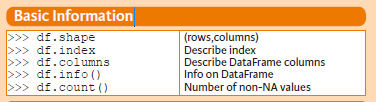

In [57]:
# inspect the dataset.
print("Shape:", sp500df.shape)
display(sp500df.head())
sp500df.info()


Shape: (500, 19)


,IDByMarketCap,Ticker,BookValuePerShare,Price_over_Book,PE_Ratio,SharesOutstanding,MarketCap,EPS,Price,Earnings,Company,SEC.filings,GICSSector,GICSSubIndustry,HQ.Location,Date.First.Added,CIK,Founded,BookValue
0,1,AAPL,3.610,46.880890,27.973555,1.607080e+10,2.719820e+12,6.05,169.240008,9.722834e+10,Apple Inc.,reports,Information Technology,"Technology Hardware, Storage & Peripherals","Cupertino, California",11/30/1982,320193,1977,5.801559e+10
1,2,MSFT,22.313,12.959262,29.964767,7.457890e+09,2.156520e+12,9.65,289.160001,7.196864e+10,Microsoft,reports,Information Technology,Systems Software,"Redmond, Washington",6/1/1994,789019,1975,1.664079e+11
2,3,GOOG,19.530,6.177675,22.593632,6.163000e+09,1.567860e+12,5.34,254.398637,3.291042e+10,Alphabet Inc. (Class C),reports,Communication Services,Interactive Media & Services,"Mountain View, California",4/3/2006,1652044,1998,1.203634e+11
3,4,GOOGL,19.530,6.129032,22.332088,5.996000e+09,1.566650e+12,5.36,261.281768,3.213856e+10,Alphabet Inc. (Class A),reports,Communication Services,Interactive Media & Services,"Mountain View, California",4/3/2014,1652044,1998,1.171019e+11
4,5,AMZN,12.904,11.057812,129.718190,1.018760e+10,1.453670e+12,1.10,142.690007,1.120636e+10,Amazon,reports,Consumer Discretionary,Internet & Direct Marketing Retail,"Seattle, Washington",11/18/2005,1018724,1994,1.314608e+11


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IDByMarketCap      500 non-null    int64  
 1   Ticker             500 non-null    str    
 2   BookValuePerShare  500 non-null    float64
 3   Price_over_Book    500 non-null    float64
 4   PE_Ratio           485 non-null    float64
 5   SharesOutstanding  500 non-null    float64
 6   MarketCap          500 non-null    float64
 7   EPS                500 non-null    float64
 8   Price              500 non-null    float64
 9   Earnings           500 non-null    float64
 10  Company            500 non-null    str    
 11  SEC.filings        500 non-null    str    
 12  GICSSector         500 non-null    str    
 13  GICSSubIndustry    500 non-null    str    
 14  HQ.Location        500 non-null    str    
 15  Date.First.Added   455 non-null    str    
 16  CIK                500 non-null    in

## <font color="orange">**Data Selection: `df.loc` vs `df.iloc`**</font>

* **Select a single column (e.g., `'Country'`) will return a <font color="orange">Series.</font>**
* **Select a collection of column(s) by passing a list (e.g., `['Country']`, or `['Country', 'Capital']` will return a <font color="orange">DataFrame</font>.**

**Select the columns: SharesOutstanding, and Earnings.**

Enter your Python code in the cell below.

In [58]:
# Select two columns as a DataFrame.
sp500df.loc[:, ["SharesOutstanding", "Earnings"]].head()

,SharesOutstanding,Earnings
0,1.607080e+10,9.722834e+10
1,7.457890e+09,7.196864e+10
2,6.163000e+09,3.291042e+10
3,5.996000e+09,3.213856e+10
4,1.018760e+10,1.120636e+10


## <font color="orange">**Filtering Data with Logic Conditions and Computing Descriptive Statistics**</font>

**How many unique GICSSubIndustry names in the dataset?**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [59]:
# nunique() counts distinct non-missing sub-industry names.
unique_subindustries = sp500df["GICSSubIndustry"].nunique()
print("Number of unique GICSSubIndustry names:", unique_subindustries)

Number of unique GICSSubIndustry names: 121


**Find the rows where the 'GICSSubIndustry' is in 'Pharmaceuticals'.**

Enter your Python code in the cell below.

In [60]:
# Create a Boolean condition and use it to filter the rows.
pharmaceuticals = sp500df[sp500df["GICSSubIndustry"] == "Pharmaceuticals"]
pharmaceuticals

,IDByMarketCap,Ticker,BookValuePerShare,Price_over_Book,PE_Ratio,SharesOutstanding,MarketCap,EPS,Price,Earnings,Company,SEC.filings,GICSSector,GICSSubIndustry,HQ.Location,Date.First.Added,CIK,Founded,BookValue
9,10,JNJ,29.044,5.876257,24.842794,2.629180e+09,4.487220e+11,6.87,170.670003,1.806247e+10,Johnson & Johnson,reports,Health Care,Pharmaceuticals,"New Brunswick, New Jersey",6/30/1973,200406,1886,7.636190e+10
18,19,LLY,8.989,33.886970,48.582134,9.501750e+08,2.894330e+11,6.27,304.609998,5.957597e+09,Eli Lilly and Company,reports,Health Care,Pharmaceuticals,"Indianapolis, Indiana",12/31/1970,59478,1876,8.541123e+09
20,21,PFE,14.742,3.388279,9.642858,5.610900e+09,2.802640e+11,5.18,49.949998,2.906446e+10,Pfizer,reports,Health Care,Pharmaceuticals,"New York City, New York",3/4/1957,78003,1849,8.271589e+10
22,23,ABBV,8.288,17.005308,19.934937,1.768100e+09,2.491960e+11,7.07,140.940006,1.250047e+10,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",12/31/2012,1551152,2013 (1888),1.465401e+10
26,27,MRK,17.070,5.224957,13.616794,2.533280e+09,2.259430e+11,6.55,89.190005,1.659298e+10,Merck & Co.,reports,Health Care,Pharmaceuticals,"Kenilworth, New Jersey",3/4/1957,310158,1891,4.324309e+10
93,94,ZTS,9.774,17.808472,39.469387,4.681390e+08,8.148428e+10,4.41,174.060000,2.064493e+09,Zoetis,reports,Health Care,Pharmaceuticals,"Parsippany, New Jersey",6/21/2013,1555280,1952,4.575591e+09
330,331,CTLT,25.856,4.364171,41.333332,1.792130e+08,2.022239e+10,2.73,112.840002,4.892515e+08,Catalent,reports,Health Care,Pharmaceuticals,"Somerset, New Jersey",9/21/2020,1596783,2007,4.633731e+09
430,431,VTRS,16.337,0.659240,71.800000,1.212330e+09,1.305679e+10,0.15,10.770001,1.818495e+08,Viatris,reports,Health Care,Pharmaceuticals,"Pittsburgh, Pennsylvania",4/23/2004,1792044,1961,1.980583e+10
489,490,OGN,-4.471,-7.049877,7.262672,2.536370e+08,8.016482e+09,4.34,31.606122,1.100785e+09,Organon & Co.,reports,Health Care,Pharmaceuticals,"Jersey City, New Jersey",6/3/2021,1821825,2021,-1.134011e+09


**Calculate the median 'BookValuePerShare' of the companies in the "Utilities" sector.**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [61]:
# Filter Utilities companies and calculate their median BookValuePerShare.
utilities = sp500df[sp500df["GICSSector"] == "Utilities"]
utilities_median_bvps = utilities["BookValuePerShare"].median()
print("Median BookValuePerShare for Utilities:", utilities_median_bvps)

Median BookValuePerShare for Utilities: 33.830999999999996


**What is the total market cap of the companies in the materials sector?**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [62]:
# Filter the Materials sector and add its MarketCap values.
materials = sp500df[sp500df["GICSSector"] == "Materials"]
materials_market_cap = materials["MarketCap"].sum()
print("Total MarketCap for Materials:", materials_market_cap)

Total MarketCap for Materials: 901987622528.0


**How many companies are in 'Communication Services' sector?**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [63]:
# The Boolean condition is True for rows in Communication Services.
communication_services_count = (sp500df["GICSSector"] == "Communication Services").sum()
print("Number of Communication Services companies:", communication_services_count)

Number of Communication Services companies: 26


**How many companies with negative earnings per share (EPS)?**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [64]:
# Count the rows where EPS is below zero.
negative_eps_count = (sp500df["EPS"] < 0).sum()
print("Number of companies with negative EPS:", negative_eps_count)

Number of companies with negative EPS: 15


## <font color="orange">**Sorting Series `ser.sort_values()` and DataFrame `df.sort_values(by=)`**</font>

Related functions:
* `ser.nlargest()`, `ser.nsmallest()`
* `df.nlargest()`, `df.nsmallest()`

To get the top or bottom `n` rows:

* `ser.sort_values().head(n)` or `ser.sort_values().tail(n)`
* `df.sort_values(by=).head(n)` or `df.sort_values(by=).tail(n)`

**Find the company with the smallest MarketCap in the "Real Estate" sector.**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [65]:
# First filter Real Estate, then sort MarketCap from smallest to largest.
real_estate = sp500df[sp500df["GICSSector"] == "Real Estate"]
smallest_real_estate = real_estate.sort_values(by="MarketCap").head(1)
display(smallest_real_estate[["Ticker", "MarketCap"]])
print("Ticker with the smallest MarketCap:", smallest_real_estate.iloc[0]["Ticker"])

,Ticker,MarketCap
495,VNO,6.039707e+09


Ticker with the smallest MarketCap: VNO


**For the ten companies in the "Information Technology" sector with the greatest MarketCap, what is the mean earnings?**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [66]:
# Filter Information Technology and keep its ten largest MarketCap companies.
information_technology = sp500df[sp500df["GICSSector"] == "Information Technology"]
top_10_it = information_technology.sort_values(by="MarketCap", ascending=False).head(10)
display(top_10_it[["Ticker", "MarketCap", "Earnings"]])
mean_it_earnings = top_10_it["Earnings"].mean()
print("Mean earnings of the top 10 IT companies:", mean_it_earnings)

,Ticker,MarketCap,Earnings
0,AAPL,2.719820e+12,9.722834e+10
1,MSFT,2.156520e+12,7.196864e+10
8,NVDA,4.509770e+11,9.292668e+09
10,V,4.469820e+11,1.110172e+10
15,MA,3.414980e+11,9.462132e+09
27,AVGO,2.229040e+11,8.176505e+09
29,ORCL,2.066390e+11,6.422481e+09
30,ADBE,2.051710e+11,4.825080e+09
32,ACN,2.003500e+11,6.521570e+09
35,CSCO,1.905670e+11,1.180174e+10


Mean earnings of the top 10 IT companies: 23680086930.9


**Sort the data in descending order of the "EPS" (earning per share) column. Which ticker has the highest EPS?**

In [67]:
# Sort EPS in descending order; the first row has the highest EPS.
eps_descending = sp500df.sort_values(by="EPS", ascending=False)
display(eps_descending[["Ticker", "EPS"]].head())
print("Ticker with the highest EPS:", eps_descending.iloc[0]["Ticker"])

,Ticker,EPS
412,NVR,397.85
180,AZO,113.49
110,REGN,49.30
66,GS,44.28
95,BKNG,38.03


Ticker with the highest EPS: NVR


## <font color="orange">**Group By: split-apply-combine**</font>

* `df.groupby().___` or `ser.groupby().__`

* Calculate group summary statistics, like `count()`,`mean()`,`min()`,`max()`,`median()`,`cumsum()`,`sum()`,`std()`,and `rank()`.

**`GroupBy` Aggregation Functions**: https://wesmckinney.com/book/data-aggregation#tbl-table_opt_groupby_methods

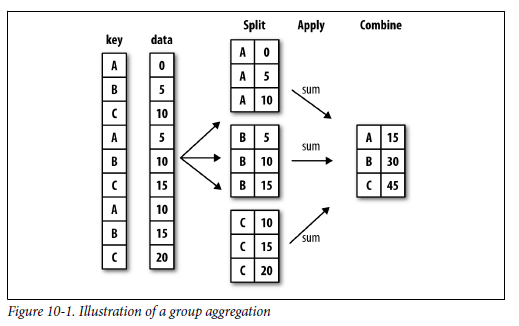

**Among the 25 companies with the greatest BookValue, how many of them are from the "Industrials" sector?**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [68]:
# First, I sort BookValue from the largest to the smallest.
# Then I use head(25) because the question asks about the top 25 companies.
top_25_bookvalue = sp500df.sort_values(by="BookValue", ascending=False).head(25)

# I display a few columns to check whether the sorting worked as expected.
display(top_25_bookvalue[["Ticker", "GICSSector", "BookValue"]])

# Next, I split the top 25 companies into sector groups and count each group.
sector_counts = top_25_bookvalue.groupby("GICSSector").size().sort_values(ascending=False)
display(sector_counts)

# Finally, I select the count for the Industrials group.
# Using .get() avoids an error if the label is not present in the top 25.
industrials_count = sector_counts.get("Industrials", 0)
print("Answer - number of Industrials companies:", industrials_count)

,Ticker,GICSSector,BookValue
14,JPM,Financials,2.533037e+11
19,BAC,Financials,2.399885e+11
76,C,Financials,1.800191e+11
11,XOM,Energy,1.773164e+11
1,MSFT,Information Technology,1.664079e+11
43,WFC,Financials,1.581247e+11
17,CVX,Energy,1.535545e+11
4,AMZN,Consumer Discretionary,1.314608e+11
2,GOOG,Communication Services,1.203634e+11
62,T,Communication Services,1.177500e+11


GICSSector
Communication Services    8
Financials                6
Health Care               4
Energy                    2
Information Technology    2
Consumer Discretionary    1
Consumer Staples          1
Industrials               1
dtype: int64

Answer - number of Industrials companies: 1


**Calculate the maximum and minimum BookValue by GICSSector.**

Enter your Python code in the cell below and add a comment (#) to answer the questions.

In [69]:
# I first select the two columns needed for this question.
sector_bookvalue = sp500df[["GICSSector", "BookValue"]]
display(sector_bookvalue.head())

# Split the rows by GICSSector, then apply max() and min() to BookValue.
# agg() lets me calculate both summary statistics in one step.
bookvalue_summary = (
    sector_bookvalue
    .groupby("GICSSector")["BookValue"]
    .agg(["max", "min"])
)

# I rename the columns so the final result is easier to understand.
bookvalue_summary = bookvalue_summary.rename(
    columns={"max": "Maximum BookValue", "min": "Minimum BookValue"}
)

# The output table is the answer for every sector.
bookvalue_summary

,GICSSector,BookValue
0,Information Technology,5.801559e+10
1,Information Technology,1.664079e+11
2,Communication Services,1.203634e+11
3,Communication Services,1.171019e+11
4,Consumer Discretionary,1.314608e+11


,Maximum BookValue,Minimum BookValue
GICSSector,,
Communication Services,1.203634e+11,-4.527776e+08
Consumer Discretionary,1.314608e+11,-8.669754e+09
Consumer Staples,7.670560e+10,-9.043633e+09
Energy,1.773164e+11,5.720805e+08
Financials,2.533037e+11,-1.026492e+09
Health Care,8.271589e+10,-3.680234e+09
Industrials,7.031288e+10,-1.489694e+10
Information Technology,1.664079e+11,-6.219947e+09
Materials,3.967392e+10,1.996871e+08


# **2.Debugging Final Exam Part II**

> <font color="green">*You spend much more time reading code than writing code.*

> <font color="green">*A lot of your programming will always be trial and error.*

Please review the answers for the questions in the final exam part II, and see whether you can find the "bugs" (errors) and fix them.

* **Key functions**: `df.groupby()`,aggregate functions (e.g. `median()`, `mean()`), `sort_values()`, `head()`, etc.
* **Key operations**:
    * dataframe/series **filtering** using comparison operators: `==`, `>`, `<`.
    * dataframe/series **selection** using `df[]`, `df.loc[;]` or `df.iloc[;]`.  


**Reference**

* Pandas API Reference: https://pandas.pydata.org/docs/reference/index.html

## **Data Dictionary of the Forbes2000 dataset**:

For each observation, the following eight variables are available:

* "rank" - the ranking of the company
* "name" - the name of the company,
* "country" - the country the company is situated in,
* "category" - a category describing the products the company produces,
* "sales" - the amount of sales of the company in billion US dollars,
* "profits" - the profit of the company in billion US dollars,
* "assets" - the assets of the company in billion US dollars,
* "marketvalue" - the market value of the company in billion US dollars.

### **Read the CSV file**

Read the `csv` file.

In [70]:
# read dataset for Part II:Forbes2000.csv
filepath2 = "Forbes2000.csv"
forbes2000df = pd.read_csv(filepath2)

In [71]:
# Check the dataset before solving the questions.
print("Shape:", forbes2000df.shape)
display(forbes2000df.head())
print("Columns:", forbes2000df.columns.tolist())
forbes2000df.info()

Shape: (2000, 8)


,rank,name,country,category,sales,profits,assets,marketvalue
0,1,Citigroup,United States,Banking,94.71,17.85,1264.03,255.30
1,2,General Electric,United States,Conglomerates,134.19,15.59,626.93,328.54
2,3,American Intl Group,United States,Insurance,76.66,6.46,647.66,194.87
3,4,ExxonMobil,United States,Oil & gas operations,222.88,20.96,166.99,277.02
4,5,BP,United Kingdom,Oil & gas operations,232.57,10.27,177.57,173.54


Columns: ['rank', 'name', 'country', 'category', 'sales', 'profits', 'assets', 'marketvalue']
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rank         2000 non-null   int64  
 1   name         2000 non-null   str    
 2   country      2000 non-null   str    
 3   category     2000 non-null   str    
 4   sales        2000 non-null   float64
 5   profits      1995 non-null   float64
 6   assets       2000 non-null   float64
 7   marketvalue  2000 non-null   float64
dtypes: float64(4), int64(1), str(3)
memory usage: 125.1 KB


## Q1
**Calculate the median profit for the companies in the United States, United Kingdom, France, and Germany respectively.**

### Debugging

In [ ]:
# Forbes2000df.groupby(by=' country').median()['profits'][
#     ['United State', 'United Kingdom', 'France', ' Germany']
# ]

### Answer

In [ ]:
countries_q1 = ["United States", "United Kingdom", "France", "Germany"]
median_profit_q1 = (
    forbes2000df.groupby("country")["profits"].median().loc[countries_q1]
)
median_profit_q1

country
United States     0.240
United Kingdom    0.205
France            0.190
Germany           0.230
Name: profits, dtype: float64

## Q2.
 **The number of German companies with negative profits**

### Debugging

In [ ]:
# Q2. The number of German companies with negative profits
germany_pft = forbes2000df[forbes2000df['country'] == 'Germany']['profits']
neg_pft = germany_pft < 0
print("Boolean values in the first attempt:")
display(neg_pft.head())
print("Why count() was not enough:", neg_pft.count())

Boolean values in the first attempt:


20    False
33    False
34    False
68    False
70    False
Name: profits, dtype: bool

Why count() was not enough: 65


In [ ]:
# forbes2000df[forbes2000df['country'] == 'Germany'] < 0
# The corrected answer below compares only the numeric profits column.

### Answer

In [ ]:
german_companies = forbes2000df[forbes2000df["country"] == "Germany"]
german_negative_profit_count = (german_companies["profits"] < 0).sum()
print("German companies with negative profits:", german_negative_profit_count)

German companies with negative profits: 13


In [77]:
# Alternative check using query(); len() counts the filtered rows.
german_negative_profit = forbes2000df.query("country == 'Germany' and profits < 0")
display(german_negative_profit[["name", "country", "profits"]].head())
print("Check with len():", len(german_negative_profit))

,name,country,profits
349,Allianz Worldwide,Germany,-1.23
363,Deutsche Telekom,Germany,-25.83
396,E.ON,Germany,-0.73
430,HVB-HypoVereinsbank,Germany,-0.87
499,Commerzbank,Germany,-0.31


Check with len(): 13


## Q3

**To which business category do most of the companies in Bermuda belong?**

### Debugging

In [78]:
# First filter the dataset to companies located in Bermuda.
bermuda_companies = forbes2000df[forbes2000df["country"] == "Bermuda"]
display(bermuda_companies[["name", "category"]].head())

,name,category
75,Tyco International,Conglomerates
193,ACE,Insurance
326,XL Capital,Insurance
369,Ingersoll-Rand,Conglomerates
377,Accenture,Software & services


In [79]:
# Count the number of Bermuda companies in each business category.
bermuda_category_counts = bermuda_companies["category"].value_counts()
bermuda_category_counts

category
Insurance               10
Conglomerates            2
Oil & gas operations     2
Software & services      1
Food drink & tobacco     1
Food markets             1
Capital goods            1
Banking                  1
Media                    1
Name: count, dtype: int64

### Answer

In [80]:
# idxmax() returns the category label with the largest count.
most_common_bermuda_category = bermuda_category_counts.idxmax()
print("Most common business category in Bermuda:", most_common_bermuda_category)

Most common business category in Bermuda: Insurance


In [ ]:
# also check the frequency so the conclusion is supported by the data.
print("Number of companies in that category:", bermuda_category_counts.max())

Number of companies in that category: 10


## Q4.
Choose the top 50 profitable companies from the Forbes data set. What is the minimum assets (of these 50 companies)? (1 mark)


### Debugging

In [82]:
#Q4. Choose the top 50 profitable companies from the Forbes data set. What is the minimum assets
# Debugging note: iloc[0:51] returns 51 rows, and sum() answers a different question.
profit_sort = forbes2000df.sort_values(by = 'profits', ascending=False)
slice_profit_sort = profit_sort.iloc[0:50]
print("Rows selected after correcting the slice:", len(slice_profit_sort))

Rows selected after correcting the slice: 50


In [83]:
#Q4. Choose the top 50 profitable companies from the Forbes data set. What is the minimum assets
top_50 = forbes2000df.sort_values("profits", ascending=False).head(50)
# idxmin() gives the row label, while min() gives the requested asset value.
print("Row label of minimum assets:", top_50["assets"].idxmin())
print("Minimum asset value:", top_50["assets"].min())

Row label of minimum assets: 101
Minimum asset value: 27.34


### Answer

In [84]:
# Correct the slice to exactly 50 rows and use min(), not sum().
top_50_profitable = forbes2000df.sort_values(by="profits", ascending=False).head(50)
minimum_assets_top_50 = top_50_profitable["assets"].min()
print("Minimum assets among the top 50 profitable companies:", minimum_assets_top_50)

Minimum assets among the top 50 profitable companies: 27.34


In [85]:
# Show the company row as a check of the minimum value.
minimum_assets_row = top_50_profitable.nsmallest(1, "assets")
display(minimum_assets_row[["name", "profits", "assets"]])

,name,profits,assets
101,Coca-Cola,4.35,27.34


## Q5.

**Find the average value of sales for the companies in each country.**


In [86]:
# Split by country and calculate the mean sales for each group.
average_sales_by_country = forbes2000df.groupby("country")["sales"].mean()
average_sales_by_country

country
Africa                           6.820000
Australia                        5.244595
Australia/ United Kingdom       11.595000
Austria                          4.142500
Bahamas                          1.350000
                                  ...    
United Kingdom/ Australia       10.010000
United Kingdom/ Netherlands      7.540000
United Kingdom/ South Africa     2.060000
United States                   10.058256
Venezuela                        0.980000
Name: sales, Length: 61, dtype: float64

### Answer

In [87]:
# Sort the result to make country differences easier to inspect.
average_sales_by_country.sort_values(ascending=False)

country
Netherlands/ United Kingdom    92.100000
Germany                        20.781385
France                         20.102063
Netherlands                    17.020714
Korea                          15.005000
                                 ...    
Jordan                          1.330000
Pakistan                        1.230000
France/ United Kingdom          1.010000
Venezuela                       0.980000
Peru                            0.170000
Name: sales, Length: 61, dtype: float64

## Q6.
**Count the number of companies in each country with profits above 5 billion US dollars.**

### Debugging

In [88]:
# First make a Boolean condition for profits above 5 billion dollars.
above_5_profit = forbes2000df["profits"] > 5
print("Total companies above 5 billion profit:", above_5_profit.sum())

Total companies above 5 billion profit: 32


In [89]:
# Apply the condition and inspect the filtered observations.
high_profit_companies = forbes2000df[above_5_profit]
display(high_profit_companies[["name", "country", "profits"]].head())

,name,country,profits
0,Citigroup,United States,17.85
1,General Electric,United States,15.59
2,American Intl Group,United States,6.46
3,ExxonMobil,United States,20.96
4,BP,United Kingdom,10.27


In [90]:
# Group the filtered rows by country and count their rows.
high_profit_country_counts = high_profit_companies.groupby("country").size()
high_profit_country_counts.sort_values(ascending=False)

country
United States                  20
United Kingdom                  3
Switzerland                     3
China                           1
France                          1
Netherlands/ United Kingdom     1
Japan                           1
Germany                         1
South Korea                     1
dtype: int64

### Answer

In [91]:
# Final answer: countries and their number of companies with profits above 5.
q6_answer = (
    forbes2000df[forbes2000df["profits"] > 5]
    .groupby("country")
    .size()
    .sort_values(ascending=False)
)
q6_answer

country
United States                  20
United Kingdom                  3
Switzerland                     3
China                           1
France                          1
Netherlands/ United Kingdom     1
Japan                           1
Germany                         1
South Korea                     1
dtype: int64

In [92]:
# Convert the Series to a clearly labeled DataFrame for readability.
q6_answer.rename("company_count").reset_index()

,country,company_count
0,United States,20
1,United Kingdom,3
2,Switzerland,3
3,China,1
4,France,1
5,Netherlands/ United Kingdom,1
6,Japan,1
7,Germany,1
8,South Korea,1


## Q7.
**How many of the top 20 companies by market value are based in the United States, and how many are based in the United Kingdom?**

### Debugging

### Answer

In [94]:
# Select exactly the top 20 companies by market value.
top_20_market_value = forbes2000df.nlargest(20, "marketvalue")
display(top_20_market_value[["name", "country", "marketvalue"]])

# Count the two requested countries within the top 20.
top_20_country_counts = top_20_market_value["country"].value_counts()
us_count = top_20_country_counts.get("United States", 0)
uk_count = top_20_country_counts.get("United Kingdom", 0)
print("United States:", us_count)
print("United Kingdom:", uk_count)

,name,country,marketvalue
1,General Electric,United States,328.54
30,Microsoft,United States,287.02
23,Pfizer,United States,285.27
3,ExxonMobil,United States,277.02
0,Citigroup,United States,255.30
9,Wal-Mart Stores,United States,243.74
57,Intel,United States,196.87
2,American Intl Group,United States,194.87
6,HSBC Group,United Kingdom,177.96
353,Vodafone,United Kingdom,174.61


United States: 15
United Kingdom: 4


## Q8
**Construct a new column to calculate the price-to-sales ratio. Among companies with negative profits, which company has the lowest P/S ratio?**

### Debugging

In [ ]:
# Price-to-sales ratio is market value divided by sales.
forbes_ps = forbes2000df.copy()
forbes_ps["price_to_sales"] = forbes_ps["marketvalue"] / forbes_ps["sales"]

In [96]:
# Keep only companies with negative profits.
negative_profit_companies = forbes_ps[forbes_ps["profits"] < 0]
display(negative_profit_companies[["name", "profits", "price_to_sales"]].head())

,name,profits,price_to_sales
349,Allianz Worldwide,-1.23,0.496181
353,Vodafone,-15.51,3.638466
363,Deutsche Telekom,-25.83,1.492553
371,Credit Suisse Group,-2.40,1.161010
373,France Telecom,-21.78,1.109847


In [97]:
# Sort the ratio from low to high to inspect the candidate answer.
negative_profit_companies.sort_values("price_to_sales").head()

,rank,name,country,category,sales,profits,assets,marketvalue,price_to_sales
1599,1600,Hyundai South,Korea,Trading companies,15.11,-0.15,0.83,0.05,0.003309
1449,1450,Federal-Mogul,United States,Consumer durables,5.49,-0.18,8.05,0.02,0.003643
1038,1039,UAL,United States,Transportation,13.58,-3.78,22.37,0.18,0.013255
934,935,Nissho Iwai-Nichimen,Japan,Trading companies,54.72,-1.00,26.80,0.88,0.016082
1874,1875,MyTravel Group,United Kingdom,Hotels restaurants & leisure,6.97,-1.52,2.55,0.12,0.017217


### Answer


In [98]:
# Avoid division by zero before calculating the final ratio.
valid_sales = forbes2000df[forbes2000df["sales"] != 0].copy()
valid_sales["price_to_sales"] = valid_sales["marketvalue"] / valid_sales["sales"]

In [99]:
# Apply the negative-profit condition to the valid sales rows.
negative_profit_valid_sales = valid_sales[valid_sales["profits"] < 0]
lowest_ps_company = negative_profit_valid_sales.nsmallest(1, "price_to_sales")

In [100]:
# Final answer with the values used for the decision.
display(lowest_ps_company[["name", "profits", "sales", "marketvalue", "price_to_sales"]])
print("Company with the lowest P/S ratio:", lowest_ps_company.iloc[0]["name"])

,name,profits,sales,marketvalue,price_to_sales
1599,Hyundai South,-0.15,15.11,0.05,0.003309


Company with the lowest P/S ratio: Hyundai South


## Q9.
**How many companies in Germany with assets above three billion dollars? Which industry/category does the company with the greatest profit belong to?**

### Debugging

In [101]:
# Begin by filtering all companies located in Germany.
germany = forbes2000df[forbes2000df["country"] == "Germany"]
display(germany[["name", "category", "profits", "assets"]].head())

,name,category,profits,assets
20,DaimlerChrysler,Consumer durables,5.12,195.58
33,Deutsche Bank Group,Diversified financials,1.53,792.49
34,Siemens Group,Conglomerates,2.81,85.47
68,Deutsche Post,Transportation,1.64,169.33
70,Volkswagen Group,Consumer durables,2.71,112.87


In [102]:
# From the German subset, keep companies with assets above 3.
germany_assets_above_3 = germany[germany["assets"] > 3]
print("Rows after both filters:", len(germany_assets_above_3))

Rows after both filters: 56


### Answer

In [103]:
# Answer to the first part.
germany_assets_count = germany_assets_above_3.shape[0]
print("German companies with assets above 3 billion:", germany_assets_count)

German companies with assets above 3 billion: 56


In [104]:
# Within that filtered set, find the company with the greatest profit.
greatest_profit_germany = germany_assets_above_3.nlargest(1, "profits")
display(greatest_profit_germany[["name", "category", "profits", "assets"]])
print("Category of the greatest-profit company:", greatest_profit_germany.iloc[0]["category"])

,name,category,profits,assets
20,DaimlerChrysler,Consumer durables,5.12,195.58


Category of the greatest-profit company: Consumer durables


# 3.**Logical Operators in Pandas: `&`, `|`, `~`, `(...)`**

**Python's `and`, `or` and `not` logical operators are designed to work with scalars.** A scalar value refers to a single value. A scalar value is in contrast to a set of values. **In Pandas, we often work with Series or DataFrame (involving a collections of values)**, so pandas developed its own element-wise logical operators for working with Series and DataFrame.  

* `&`: and
* `|`: or
* `~`: not

The following in basic python (`exp1` and `exp2` are expressions which evaluate to a boolean result)

```
exp1 and exp2              # Logical AND
exp1 or exp2               # Logical OR
not exp1                   # Logical NOT
```
...will translate to...
```
(exp1) & (exp2)                # Element-wise logical AND
(exp1) | (exp2)                # Element-wise logical OR
~exp1                      # Element-wise logical NOT
```
for pandas.

* ⚠️<font color="red">**With two or more conditions, each condition must be wrapped using parentheses**</font>

> Another common operation is the use of boolean vectors to filter the data. The operators are: `|` for or, `&` for and, and `~` for not.
These **must be grouped by using parentheses**, since by default Python will evaluate an expression
> such as `df['A'] > 2 & df['B'] < 3` as `df['A'] > (2 & df['B']) < 3`,
while the desired evaluation order is `(df['A'] > 2) & (df['B'] < 3)`.  [Boolean indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#boolean-indexing)





## <font color="orange"> **Practice Questions**</font>

**Please make use of logical operators and re-write your answers for Q1 and Q9.**

* Q1. Calculate the median profit for the companies in the United States, United Kingdom, France, and Germany respectively.

In [105]:
# Use element-wise OR (|) and wrap every condition in parentheses.
q1_country_filter = (
    (forbes2000df["country"] == "United States")
    | (forbes2000df["country"] == "United Kingdom")
    | (forbes2000df["country"] == "France")
    | (forbes2000df["country"] == "Germany")
)
q1_logical_answer = (
    forbes2000df[q1_country_filter]
    .groupby("country")["profits"]
    .median()
)
q1_logical_answer

country
France            0.190
Germany           0.230
United Kingdom    0.205
United States     0.240
Name: profits, dtype: float64

* Q9. How many companies in Germany with assets above three billion dollars?

In [106]:
# Use element-wise AND (&) because both conditions must be true.
q9_filter = (
    (forbes2000df["country"] == "Germany")
    & (forbes2000df["assets"] > 3)
)
q9_logical_answer = q9_filter.sum()
print("German companies with assets above 3 billion:", q9_logical_answer)

German companies with assets above 3 billion: 56


# 4.**Best Practice, Clean Code and Markdown**

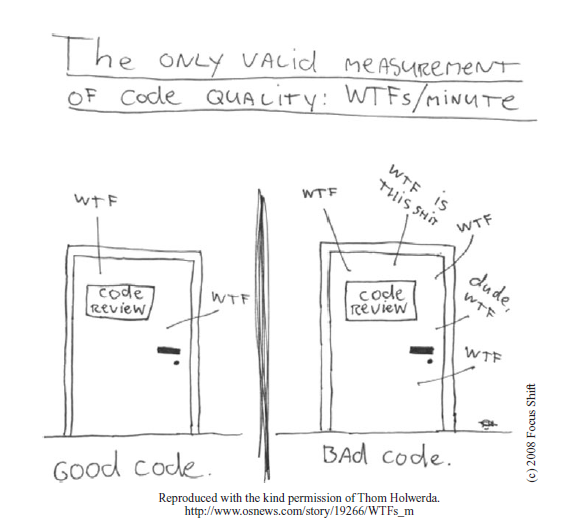

Reference:
Martin RC. **Clean Code: A Handbook of Agile Software Craftsmanship.** Pearson.

## ❗❗❗ **Basic data quality checks**

Read data dictionary and examine the data that you received.




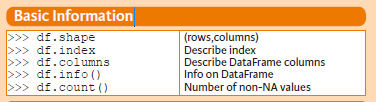

## ✔️ **Use of Comments `#` and Good Documentation**

> Nothing can be quite so helpful as a well-placed comment.

**Good comments**:

* Informative Comments.
* Explanation of Intent.
* Warning of Consequences.
* More isn't always better.


## Ⓜ️ **About Markdown in Notebooks**

> [Markdown](https://www.markdownguide.org/) is a lightweight markup language that you can use to add formatting elements to plaintext text documents.

All the Text cells are in Markdown in `ipynb` notebooks.



## Submit your Notebook

Finish your Notebook, (try) to commit every step and push it to your **private** repository. Then, share the link in the assignment on iCampus.

Alternatively, save your finished Notebook as .ipynb file and upload this in the assignment.